In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


# 1. tensorflow v2.xx 에서 v1 사용하기

In [2]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
import numpy as np
import pandas as pd

## Tensorflow
- 데이터 흐름 그래프
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session() 으로 실행
- sess.run()을 통해 값을 확인

In [5]:
# tensor = data(상수, 변수)와 연산
node1 = tf.constant('Hello, Tensoflow')
sess = tf.Session()
print(node1)
print(sess.run(node1))

Tensor("Const_1:0", shape=(), dtype=string)
b'Hello, Tensoflow'


In [7]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype=tf.float16)  # node 1에 변수
node2 = tf.constant(20, dtype=tf.float16)

node3 = tf.add(node1, node2)

sess = tf.Session()

print(sess.run([node1, node2]))
print(sess.run(node3))

[10.0, 20.0]
30.0


In [10]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)  # cast 데이터 타입을 바꾸는 함수
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [11]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1.,2.,3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)

2.0

In [15]:
# 랜덤 값을 갖는 tensor
a = tf.random_normal([1])
b = tf.random_normal([1])# 평균 0 , 표준편자가 1인 난수 실수 '1'개(정규분포를 이루는 난수)
sess = tf.Session()
sess.run([a,b])

[array([-0.5181857], dtype=float32), array([0.2773121], dtype=float32)]

In [16]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer())  # w변수의 난수 초기화
sess.run(w)

array([-1.3505137], dtype=float32)

# 2. tensorflow v1을 이용한 Linear regression
## 2.1 입력(독립)변수 x가 1개, 타겟(종속)변수 y가 1개

In [19]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight와 bias(처음엔 랜덤값으로 세팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bais')
# Hypothesis : 예측값
H = W*x +b
# cost function(손실함수 = 'mse';최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습목적 : cost가 최소가 되는 W, b를 찾아내는 것
cost는 2차 함수이므로 곡선 그래프. 곡선 위 미분값이 줄어드는 방향으로 W, b를 학습(경사하강법)
=> GradientDescentOptimizer

'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
# Session 생성
sess = tf.Session()
# W, b 변수 노드에 초기화
sess.run(tf.global_variables_initializer())
# 5000번 학습 (v2에서는 fit 함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b])
    if step%200 ==0:
        print(f'{step}번째 cost : {cost_val}, W: {W_val}, b:{b_val}')

0번째 cost : 4.511729717254639, W: [0.9079076], b:[-0.7181671]
200번째 cost : 0.10875586420297623, W: [1.3820999], b:[0.13139708]
400번째 cost : 0.04152831807732582, W: [1.2361146], b:[0.463256]
600번째 cost : 0.015857519581913948, W: [1.1459044], b:[0.66832507]
800번째 cost : 0.006055161822587252, W: [1.09016], b:[0.7950452]
1000번째 cost : 0.0023121642880141735, W: [1.0557134], b:[0.8733502]
1200번째 cost : 0.0008828918798826635, W: [1.0344274], b:[0.9217384]
1400번째 cost : 0.0003371388593222946, W: [1.0212744], b:[0.9516387]
1600번째 cost : 0.0001287310296902433, W: [1.013146], b:[0.9701161]
1800번째 cost : 4.915614772471599e-05, W: [1.0081234], b:[0.9815335]
2000번째 cost : 1.8770198948914185e-05, W: [1.0050199], b:[0.98858875]
2200번째 cost : 7.1682079578749835e-06, W: [1.0031021], b:[0.9929483]
2400번째 cost : 2.737207751124515e-06, W: [1.001917], b:[0.9956424]
2600번째 cost : 1.0456416248416645e-06, W: [1.0011849], b:[0.99730676]
2800번째 cost : 3.997873818661901e-07, W: [1.0007328], b:[0.9983347]
3000번째 co

In [20]:
# 최종적으로 나온 회귀식 :  H = W*x + b
sess.run([W,b])

[array([1.0000087], dtype=float32), array([0.9999811], dtype=float32)]

In [22]:
W_, b_ = sess.run([W,b])
W_[0], b_[0]

(1.0000087, 0.9999811)

In [23]:
def predict(x):
    return W_[0]*x+b_[0]

In [24]:
input_x = int(input('입력값 : '))
print('예측값은 ', predict(input_x))

입력값 : 3
예측값은  4.000007212162018


## 2.2 predict를 위한 placeholder 이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드

In [27]:
# x = np.array([1,2,3])
x = tf.placeholder(dtype=tf.float16)
H = 1*x +1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [29]:
# H = 2x+3
x_data = np.array([1,2,3,5, 8])
y_data = np.array([5,7,9,13,19])
# placeholder 설정 (입력변수 x, 타겟변수 y를 나중에)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bias')
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={x:x_data, 
                                                                         y:y_data})
    if step%200 ==0:
        print("{}째 : cost : {}, W:{}, b : {}".format(step,
                                                    cost_val,
                                                    W_val,
                                                    b_val))

0째 : cost : 177.49880981445312, W:[0.8230245], b : [0.32953924]
200째 : cost : 0.16684268414974213, W:[2.1389086], b : [2.2575352]
400째 : cost : 0.01641027443110943, W:[2.0435648], b : [2.7671478]
600째 : cost : 0.0016141285886988044, W:[2.013663], b : [2.9269712]
800째 : cost : 0.0001587724545970559, W:[2.004285], b : [2.9770963]
1000째 : cost : 1.5621630154782906e-05, W:[2.0013442], b : [2.9928155]
1200째 : cost : 1.5368528920589597e-06, W:[2.0004218], b : [2.9977462]
1400째 : cost : 1.512413234650012e-07, W:[2.0001323], b : [2.9992929]
1600째 : cost : 1.4966008876626802e-08, W:[2.0000417], b : [2.9997776]
1800째 : cost : 1.4865235709038416e-09, W:[2.000013], b : [2.99993]
2000째 : cost : 1.3569660672896333e-10, W:[2.000004], b : [2.9999788]
2200째 : cost : 1.3569660672896333e-10, W:[2.000004], b : [2.9999788]
2400째 : cost : 1.3569660672896333e-10, W:[2.000004], b : [2.9999788]
2600째 : cost : 1.3569660672896333e-10, W:[2.000004], b : [2.9999788]
2800째 : cost : 1.3569660672896333e-10, W:[2.0000

In [31]:
# 예측하기
sess.run(H, feed_dict={x: np.array([5,6,7])})

array([12.999999, 15.000004, 17.000008], dtype=float32)

## 2.3 scale이 다른 데이터

In [34]:
# H = 2x+3
x_data = np.array([1,2,5, 8, 10])
y_data = np.array([3,15,68,80,95])

# placeholder 설정 (입력변수 x, 타겟변수 y를 나중에)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)

# W, b
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bias')

# Hypothesis(예측값)
H = W*x + b

# 손실함수
cost = tf.reduce_mean(tf.square(H-y))

# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)

# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화

# 5000번 학습
for step in range(2001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={x:x_data, 
                                                                         y:y_data})
    if step%200 ==0:
        print("{}째 : cost : {}, W:{}, b : {}".format(step,
                                                    cost_val,
                                                    W_val,
                                                    b_val))

0째 : cost : 4858.78125, W:[7.700286], b : [0.6507112]
200째 : cost : 83.63560485839844, W:[10.207252], b : [-0.66726744]
400째 : cost : 83.49635314941406, W:[10.273804], b : [-1.1600398]
600째 : cost : 83.48359680175781, W:[10.2939625], b : [-1.3092968]
800째 : cost : 83.4824447631836, W:[10.300068], b : [-1.354506]
1000째 : cost : 83.4823226928711, W:[10.301918], b : [-1.3682002]
1200째 : cost : 83.4823226928711, W:[10.302478], b : [-1.372347]
1400째 : cost : 83.48230743408203, W:[10.302648], b : [-1.3736038]
1600째 : cost : 83.4822998046875, W:[10.302699], b : [-1.3739834]
1800째 : cost : 83.48228454589844, W:[10.302714], b : [-1.374098]
2000째 : cost : 83.48230743408203, W:[10.302718], b : [-1.3741316]


In [35]:
# cost값이 멈춤

## 2.4 scale이 다른 데이터의 linear regression 구현(scale 조정 O)
### 모든 데이터를 일정범위 내로 조정
- normalization(정규화) : 0~1 사이로 조정
    - normalization = (X - Xmin) / (Xmax - Xmin)
        * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler)
- standardization(표준화) : 평균 0, 표준편차 1로 조정
    - standardization = ( X - Xmean(평균) ) / Xstd(표준편차)
        * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler)

In [39]:
# 라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5, 8, 10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min()) / (x_data.max() - x_data.min())
scaled_y_data = (y_data - y_data.min()) / (y_data.max() - y_data.min())
scaled_x_data, scaled_y_data

(array([0.        , 0.11111111, 0.44444444, 0.77777778, 1.        ]),
 array([0.        , 0.13043478, 0.70652174, 0.83695652, 1.        ]))

In [48]:
# 라이브러리를 쓰고 정규화(MinMaxScaler)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
x_data = np.array([1,2,5, 8, 10]).reshape(-1,1) # 1차원 -> 2차원으로  축추가 필요
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
# np.column_stack([x_data, y_data])
scaled_x = MinMaxScaler()  # x_data를 정규화시킬 객체
scaled_y = MinMaxScaler()  # y_data를 정규화시킬 객체

# scaled_x.fit(x_data)
# scaled_x_data = scaled_x.transform(x_data)  # 이 2줄을 한줄로 작성
scaled_x_data = scaled_x.fit_transform(x_data)
# print(scaled_x_data)
scaled_y_data = scaled_y.fit_transform(y_data)
# print(scaled_y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data]) # 각 배열을 하나의 2차원 배열로 column_stack

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [54]:
# placeholder 설정 (입력변수 x, 타겟변수 y를 나중에)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)

# W, b
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bias')

# Hypothesis(예측값)
H = W*x + b

# 손실함수
cost = tf.reduce_mean(tf.square(H-y))

# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)

# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화

# 5000번 학습
for step in range(10001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={x:scaled_x_data, 
                                                                         y:scaled_y_data})
    if step%1000 ==0:
        print("{}째 : cost : {}, W:{}, b : {}".format(step,
                                                    cost_val,
                                                    W_val,
                                                    b_val))

0째 : cost : 1.7559852600097656, W:[-0.08149213], b : [1.8245347]
1000째 : cost : 0.25227323174476624, W:[-0.20234491], b : [0.80129194]
2000째 : cost : 0.15618900954723358, W:[0.02055771], b : [0.59397495]
3000째 : cost : 0.10164833068847656, W:[0.22339284], b : [0.47945735]
4000째 : cost : 0.067461296916008, W:[0.38623673], b : [0.39283708]
5000째 : cost : 0.04600806534290314, W:[0.51541483], b : [0.3245566]
6000째 : cost : 0.03254537284374237, W:[0.6177611], b : [0.2704947]
7000째 : cost : 0.024097073823213577, W:[0.6988379], b : [0.22767058]
8000째 : cost : 0.018795449286699295, W:[0.7630648], b : [0.19374666]
9000째 : cost : 0.015468502417206764, W:[0.8139435], b : [0.16687316]
10000째 : cost : 0.013380734249949455, W:[0.85424805], b : [0.14558475]


In [64]:
# 예측 : 모델에 scale 조정된 값으로 예측 -> 스케일 조정된 y 값 -> 스케일 전 y 값으로 반환
scaled_input = scaled_x.transform(np.array([[2],
                                          [3]]))
print('모델예측을 위한 입력 : ', scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델예측결과 : ', scaled_output, sep='\n')
print('결과 : ', scaled_y.inverse_transform(scaled_output), sep='n' )


모델예측을 위한 입력 : 
[[0.11111111]
 [0.22222222]]
모델예측결과 : 
[[0.2405012 ]
 [0.33541763]]
결과 : n[[25.12611]
 [33.85842]]


In [68]:
# x_data 들의 예측 값
scaled_y_hat = sess.run(H, feed_dict={x : scaled_x_data})
y_hat = scaled_y.inverse_transform(scaled_y_hat)
y_hat

array([[16.393797],
       [25.12611 ],
       [51.32305 ],
       [77.52    ],
       [94.98462 ]], dtype=float32)

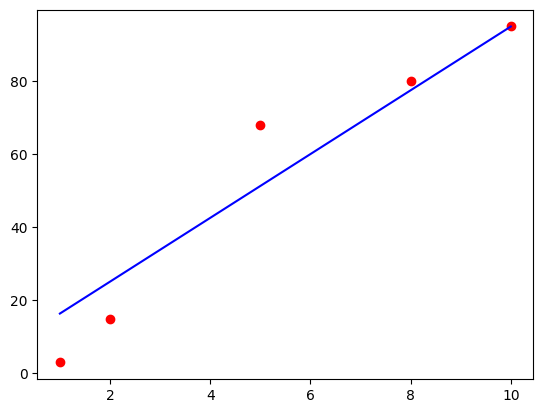

In [73]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'o', c='r')
plt.plot(x_data, y_hat, 'b')

In [77]:
# 라이브러리를 쓰고 표준화 (StandardScaler)

x_data = np.array([1,2,5, 8, 10]).reshape(-1,1) # 1차원 -> 2차원으로  축추가 필요
y_data = np.array([3,15,68,80,95]).reshape(-1,1)

scaler_x = StandardScaler()  # x_data를 정규화시킬 객체
scaler_y = StandardScaler()  # y_data를 정규화시킬 객체

scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [78]:
# placeholder 설정 (입력변수 x, 타겟변수 y를 나중에)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)

# W, b
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bias')

# Hypothesis(예측값)
H = W*x + b

# 손실함수
cost = tf.reduce_mean(tf.square(H-y))

# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)

# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화

# 5000번 학습
for step in range(10001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={x:scaled_x_data, 
                                                                         y:scaled_y_data})
    if step%1000 ==0:
        print("{}째 : cost : {}, W:{}, b : {}".format(step,
                                                    cost_val,
                                                    W_val,
                                                    b_val))

0째 : cost : 3.98213529586792, W:[-0.23423612], b : [1.5678186]
1000째 : cost : 0.13418591022491455, W:[0.80575025], b : [0.21175657]
2000째 : cost : 0.0639900416135788, W:[0.94621545], b : [0.02860082]
3000째 : cost : 0.0627094954252243, W:[0.9651872], b : [0.00386297]
4000째 : cost : 0.06268613785505295, W:[0.96774983], b : [0.00052176]
5000째 : cost : 0.06268570572137833, W:[0.96809494], b : [7.048197e-05]
6000째 : cost : 0.06268569082021713, W:[0.96813506], b : [9.538892e-06]
7000째 : cost : 0.06268569082021713, W:[0.96813506], b : [1.3118866e-06]
8000째 : cost : 0.06268569827079773, W:[0.96813506], b : [2.016292e-07]
9000째 : cost : 0.06268568336963654, W:[0.96813506], b : [5.5716278e-08]
10000째 : cost : 0.06268568336963654, W:[0.96813506], b : [4.0816197e-08]


In [80]:
# x_data 들의 예측 값
scaled_y_hat = sess.run(H, feed_dict={x : scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)
y_hat

array([[  8.929233],
       [ 19.2318  ],
       [ 50.13949 ],
       [ 81.04718 ],
       [101.6523  ]], dtype=float32)

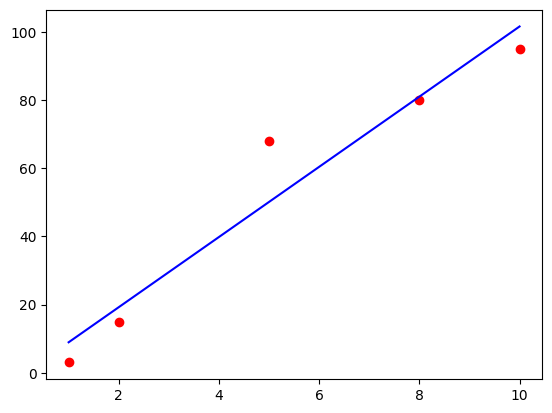

In [81]:
plt.plot(x_data, y_data, 'o', c='r')
plt.plot(x_data, y_hat, 'b')